In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# 1. Create a lightning-fast local directory inside Colab
!mkdir -p /content/local_dataset

# 2. Copy the entire dataset from your Drive to the local workspace
!cp -r /content/drive/MyDrive/Animals/* /content/local_dataset/

# 3. Verify the files copied successfully (you should see train, valid, etc.)
!ls /content/local_dataset


In [ ]:
# %%writefile data.yaml
# train: /content/local_dataset/train/images
# val: /content/local_dataset/valid/images
# test: /content/local_dataset/test/images

# nc: 4
# names: ['Elephant', 'Leopard', 'Tiger', 'Wild-Boar']

# roboflow:
#   workspace: human-wildlife
#   project: animal-alert-asxhu
#   version: 9
#   license: CC BY 4.0
#   url: https://universe.roboflow.com/human-wildlife/animal-alert-asxhu/dataset/9

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 6.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
# model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
# Train the model using your newly written data.yaml
# results = model.train(data='/content/data.yaml', epochs=100, imgsz=640) #imgsz imagesize

In [ ]:
# #saving for future use
# # Create a folder in your Google Drive to store  trained weights
# !mkdir -p /content/drive/MyDrive/YOLO_Models/

# # Copy the best weights file from Colab's temporary memory to your Google Drive
# !cp /content/runs/detect/train-6/weights/best.pt /content/drive/MyDrive/YOLO_Models/animal_detector_v1.pt



image 1/1 /content/drive/MyDrive/Animals/valid/images/4MNSEK1V6AW6_jpg.rf.f7d5b8b0c9b03751338a107fdd15945a.jpg: 640x640 1 Leopard, 461.4ms
Speed: 37.2ms preprocess, 461.4ms inference, 47.2ms postprocess per image at shape (1, 3, 640, 640)


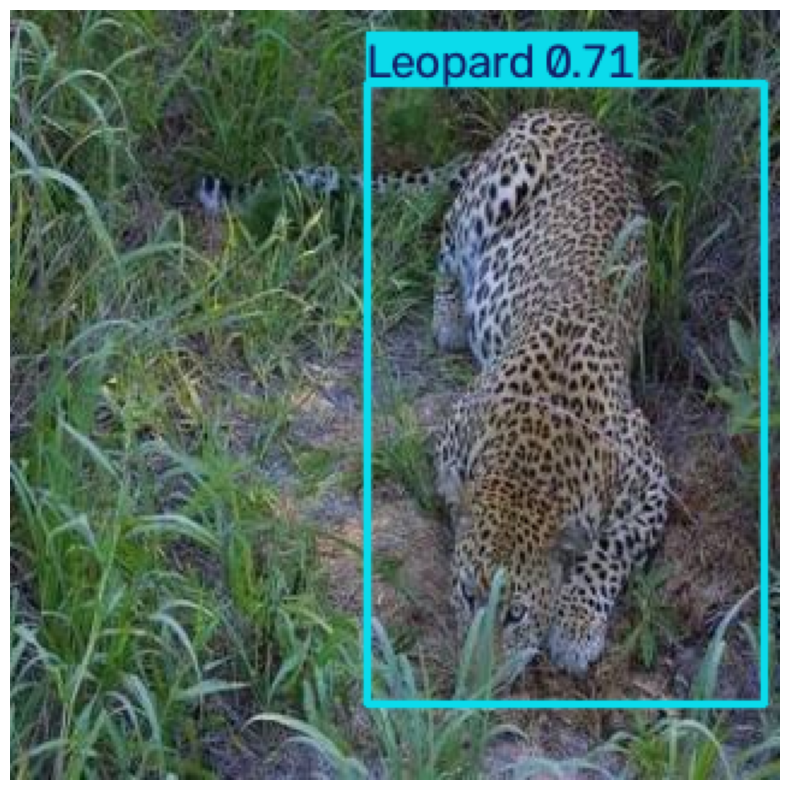

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load  trained model weights
model_path = '/content/wild_animal_detector (1).pt'
model = YOLO(model_path)

# 2. a random image from your on Google Drive
test_image_dir = '/content/drive/MyDrive/Animals/valid/images'
all_images = [f for f in os.listdir(test_image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
random_image = random.choice(all_images)
image_path = os.path.join(test_image_dir, random_image)

# 3. Run inference
results = model(image_path, conf=0.5)

# 4. Plot and display the results
for result in results:
    # Save the plotted image to a temporary file
    annotated_img = result.plot()

    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Display inside Colab
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.show()



image 1/1 /content/Camera-trap-image-from-the-pilot-in-Gabon-showing-two-elephants.jpg: 384x640 1 Elephant, 170.7ms
Speed: 6.1ms preprocess, 170.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


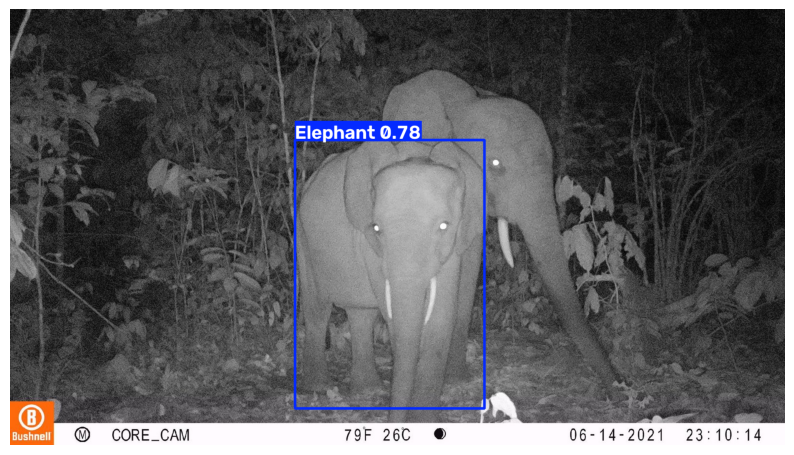

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load trained model weights
# model_path = '/content/wild_animal_detector.pt'
model_path = '/content/wild_animal_detector (1).pt'

model = YOLO(model_path)

image_path = '/content/Camera-trap-image-from-the-pilot-in-Gabon-showing-two-elephants.jpg'

results = model(image_path, conf=0.5)
# print(results)
# 4. Plot and display the image inside Colab
for result in results:
    # Get the image with bounding boxes drawn on it
    annotated_img = result.plot()

    # Convert BGR (OpenCV default) to RGB (Matplotlib default)
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Render the image
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.show()



image 1/1 /content/01092042-c241dfb8-1de6-4389-a992-75a5bc4dfaef.avif: 448x640 (no detections), 21.2ms
Speed: 2.9ms preprocess, 21.2ms inference, 4.9ms postprocess per image at shape (1, 3, 448, 640)


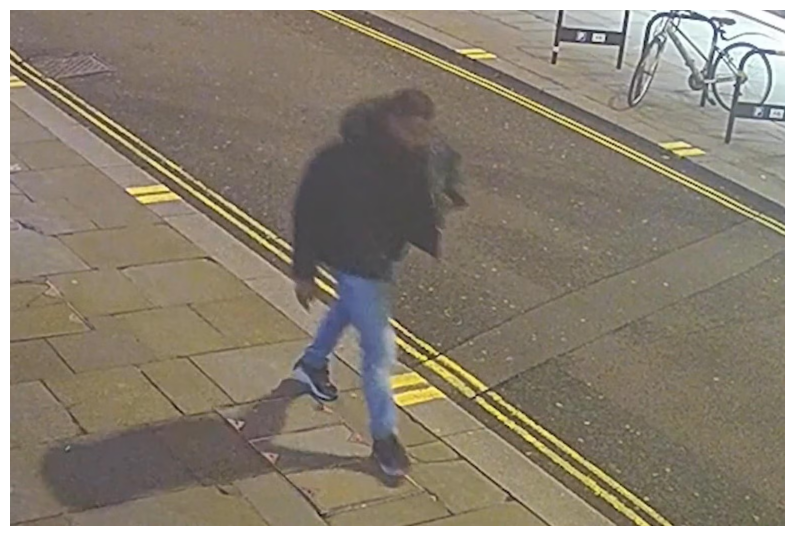

In [ ]:
# import cv2
# import matplotlib.pyplot as plt
# from ultralytics import YOLO

# # 1. Load trained model weights
# # model_path = '/content/wild_animal_detector.pt'
# model_path = '/content/wild_animal_detector (1).pt'

# model = YOLO(model_path)

# image_path = '/content/01092042-c241dfb8-1de6-4389-a992-75a5bc4dfaef.avif'

# results = model(image_path, conf=0.5)
# # print(results)
# # 4. Plot and display the image inside Colab
# for result in results:
#     # Get the image with bounding boxes drawn on it
#     annotated_img = result.plot()

#     # Convert BGR (OpenCV default) to RGB (Matplotlib default)
#     annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

#     # Render the image
#     plt.figure(figsize=(10, 10))
#     plt.imshow(annotated_img_rgb)
#     plt.axis('off')
#     plt.show()



image 1/1 /content/elephant.jpg.jpeg: 480x640 1 Elephant, 1 Tiger, 165.0ms
Speed: 6.7ms preprocess, 165.0ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


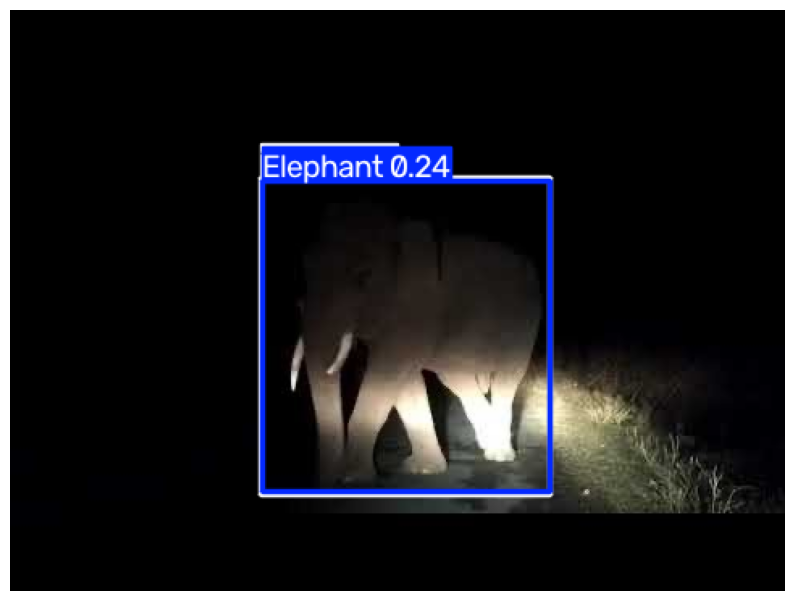

In [ ]:
# import cv2
# import matplotlib.pyplot as plt
# from ultralytics import YOLO

# # 1. Load trained model weights
# # model_path = '/content/wild_animal_detector.pt'
# model_path = '/content/wild_animal_detector (1).pt'

# model = YOLO(model_path)

# image_path = '/content/elephant.jpg.jpeg'

# results = model(image_path, conf=0.1)
# # print(results)
# # 4. Plot and display the image inside Colab
# for result in results:
#     # Get the image with bounding boxes drawn on it
#     annotated_img = result.plot()

#     # Convert BGR (OpenCV default) to RGB (Matplotlib default)
#     annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

#     # Render the image
#     plt.figure(figsize=(10, 10))
#     plt.imshow(annotated_img_rgb)
#     plt.axis('off')
#     plt.show()



image 1/1 /content/check.webp: 640x416 (no detections), 118.0ms
Speed: 5.0ms preprocess, 118.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 416)


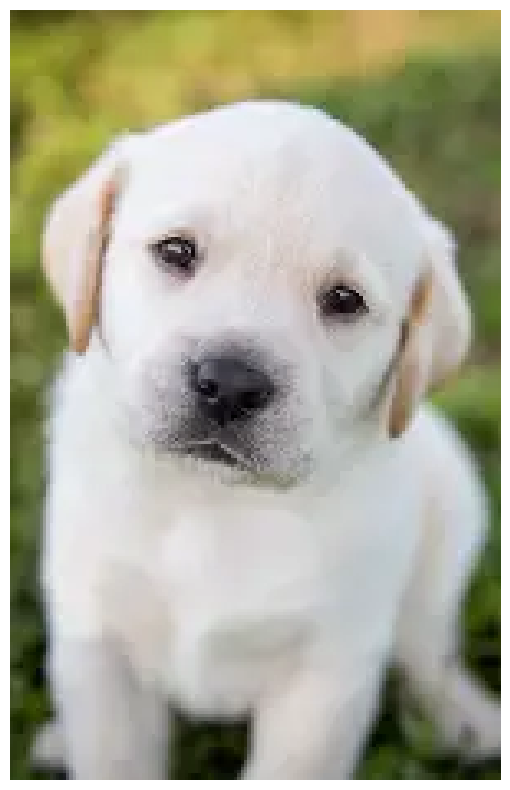

In [ ]:
# import cv2
# import matplotlib.pyplot as plt
# from ultralytics import YOLO

# # 1. Load trained model weights
# # model_path = '/content/wild_animal_detector.pt'
# model_path = '/content/wild_animal_detector (1).pt'

# model = YOLO(model_path)

# image_path = '/content/check.webp'

# results = model(image_path, conf=0.5)
# # print(results)
# # 4. Plot and display the image inside Colab
# for result in results:
#     # Get the image with bounding boxes drawn on it
#     annotated_img = result.plot()

#     # Convert BGR (OpenCV default) to RGB (Matplotlib default)
#     annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

#     # Render the image
#     plt.figure(figsize=(10, 10))
#     plt.imshow(annotated_img_rgb)
#     plt.axis('off')
#     plt.show()


In [ ]:
# wildlife_model = YOLO('/content/drive/MyDrive/YOLO_Models/animal_detector_v1.pt') # Custom: knows elephants, tigers, leopards

# metrics = wildlife_model.val(
#     data="/content/drive/MyDrive/Animals/data.yaml",
#     imgsz=640,
#     conf=0.50
# )


In [ ]:
from ultralytics import YOLO
import sys
import cv2
import time
import requests

wildlife_model = YOLO('/content/wild_animal_detector (1).pt')

last_alert_time = {}       # Key: animal_name (or track_id), Value: timestamp
alerted_track_ids = set()   # Tracks IDs that have successfully sent notifications
ALERT_COOLDOWN = 5 * 60     # 5 minutes

CLASS_NAMES = {
    0: "Elephant",
    1: "Leopard",
    2: "Tiger",
    3: "Wild-Boar"
}

results = wildlife_model.track(
    source="/content/m2-res_640p.mp4",
    conf=0.5,
    tracker="bytetrack.yaml",
    imgsz=640,
    max_det=100,
    stream=True
)

for result in results:
    if result.boxes.id is None:
        continue

    track_ids = result.boxes.id.int().cpu().tolist()
    class_ids = result.boxes.cls.int().cpu().tolist()
    confidences = result.boxes.conf.cpu().tolist()

    for track_id, class_id, confidence in zip(track_ids, class_ids, confidences):
        animal = CLASS_NAMES.get(class_id, "Unknown")

        print(f"Animal detected - {animal} | Track ID: {track_id} | Confidence: {confidence:.2f}")

        current_time = time.time()

        # FIX 2: Check global cooldown per animal type to prevent tracker jitter spam
        last_animal_alert_time = last_alert_time.get(animal, 0)
        time_since_last_alert = current_time - last_animal_alert_time

        # Only send if this specific track_id hasn't been alerted AND the global cooldown for this animal type has passed
        if track_id not in alerted_track_ids and time_since_last_alert >= ALERT_COOLDOWN:
            payload = {
                'animal': animal,
                'track_id': track_id,
                'confidence': round(confidence, 2)
            }

            try:
                response = requests.post(
                    'https://lvidya.pythonanywhere.com/api/sendnotification',
                    json=payload,
                    timeout=5
                )

                if response.ok:
                    print(f"🚀 Alert sent successfully for {animal} (ID: {track_id})")
                    alerted_track_ids.add(track_id)
                    last_alert_time[animal] = current_time  # Reset the 5-minute timer for this species
                else:
                    print(f" API responded with error: {response.status_code}")

            except requests.exceptions.RequestException as e:
                print(f"Network error sending alert: {e}")



video 1/1 (frame 1/1198) /content/m2-res_640p.mp4: 640x384 1 Tiger, 138.0ms
Animal detected - Tiger | Track ID: 1 | Confidence: 0.80
🚀 Alert sent successfully for Tiger (ID: 1)
video 1/1 (frame 2/1198) /content/m2-res_640p.mp4: 640x384 1 Tiger, 132.5ms
Animal detected - Tiger | Track ID: 1 | Confidence: 0.84
video 1/1 (frame 3/1198) /content/m2-res_640p.mp4: 640x384 1 Tiger, 128.6ms
Animal detected - Tiger | Track ID: 1 | Confidence: 0.74
video 1/1 (frame 4/1198) /content/m2-res_640p.mp4: 640x384 1 Tiger, 155.4ms
Animal detected - Tiger | Track ID: 1 | Confidence: 0.77
video 1/1 (frame 5/1198) /content/m2-res_640p.mp4: 640x384 1 Tiger, 144.0ms
Animal detected - Tiger | Track ID: 1 | Confidence: 0.82
video 1/1 (frame 6/1198) /content/m2-res_640p.mp4: 640x384 1 Tiger, 148.9ms
Animal detected - Tiger | Track ID: 1 | Confidence: 0.85
video 1/1 (frame 7/1198) /content/m2-res_640p.mp4: 640x384 1 Tiger, 135.5ms
Animal detected - Tiger | Track ID: 1 | Confidence: 0.85
video 1/1 (frame 8/1198)

Object tracking

In [ ]:
# import cv2

# from ultralytics import YOLO

# # Load the YOLO26 model
# model = YOLO("/content/wild_animal_detector (1).pt")

# # Open the video file
# video_path = "/content/AQOqoYBqnFO-Jp3rApAD9_4RA1cqrR56pfBgjpwg0ak9aWQZZbIHaz-3rFugiJnfWJ7a47Jqujhyc0THsTHrln55X0s98aUKOzduGo9wFA.mp4"
# cap = cv2.VideoCapture(video_path)

# # Loop through the video frames
# while cap.isOpened():
#     # Read a frame from the video
#     success, frame = cap.read()

#     if success:
#         # Run YOLO26 tracking on the frame, persisting tracks between frames
#         # and using the BoT-SORT tracker backend
#         results = model.track(frame, persist=True, tracker="botsort.yaml", conf=0.5)

#         # Visualize the results on the frame
#         annotated_frame = results[0].plot()

#         # Display the annotated frame
#         plt.figure(figsize=(10, 7))
#         plt.imshow(annotated_frame)
#         plt.axis('off')
#         plt.show()

#         # Break the loop if 'q' is pressed
#         # if cv2.waitKey(1) & 0xFF == ord("q"):
#         #     break
#     else:
#         # Break the loop if the end of the video is reached
#         break

# # Release the video capture object and close the display window
# cap.release()
# cv2.destroyAllWindows()

In [ ]:
# from pathlib import Path
# from collections import Counter

# label_dir = Path("/content/drive/MyDrive/Animals/train/labels")

# class_counts = Counter()

# for file in label_dir.glob("*.txt"):
#     with open(file, "r") as f:
#         for line in f:
#             if line.strip():
#                 class_id = int(line.split()[0])
#                 class_counts[class_id] += 1

# print(class_counts)